# Investigating Netflix Movie Runtime Patterns

This notebook is written as an investigation report, not just a sequence of charts. The central claim under investigation is simple: **are Netflix movies really getting shorter, or are we seeing a catalog-mix illusion?**

To answer that, we move in stages: establish data reliability, trace temporal patterns, test competing explanations (genre and geography), and finish with a statistically grounded verdict.

## Investigation Brief

Primary hypothesis:
- Newer Netflix movie releases trend shorter in runtime.

Alternative explanations to test:
- Observed trend is mostly a composition shift in genre mix.
- Country mix changes create apparent runtime drift.
- Sparse early-year observations exaggerate or distort trend strength.

Evidence standards used in this notebook:
- descriptive EDA for pattern discovery
- robust and weighted trend diagnostics
- bootstrap uncertainty intervals
- composition-adjusted comparisons

In [115]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 25)
pd.set_option('display.width', 160)

In [116]:
netflix_df = pd.read_csv('netflix_data.csv')
netflix_df.columns = [col.strip() for col in netflix_df.columns]

initial_profile = pd.DataFrame({
    'dtype': netflix_df.dtypes.astype(str),
    'non_null': netflix_df.notna().sum(),
    'nulls': netflix_df.isna().sum(),
    'null_pct': (netflix_df.isna().mean() * 100).round(2),
    'unique': netflix_df.nunique(dropna=True)
}).sort_values(['null_pct', 'unique'], ascending=[False, False])

print(f"Rows: {len(netflix_df):,} | Columns: {netflix_df.shape[1]}")
display(initial_profile)
netflix_df.head(3)

Rows: 7,787 | Columns: 11


,dtype,non_null,nulls,null_pct,unique
director,object,5398,2389,30.68,4049
cast,object,7069,718,9.22,6831
country,object,7280,507,6.51,81
date_added,object,7777,10,0.13,1565
show_id,object,7787,0,0.00,7787
title,object,7787,0,0.00,7787
description,object,7787,0,0.00,7769
duration,int64,7787,0,0.00,206
release_year,int64,7787,0,0.00,73
genre,object,7787,0,0.00,35


,show_id,type,title,director,cast,country,date_added,release_year,duration,description,genre
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,4,In a future where the elite inhabit an island ...,International TV
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,93,After a devastating earthquake hits Mexico Cit...,Dramas
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,78,"When an army recruit is found dead, his fellow...",Horror Movies


## Phase 1: Establishing the Evidence Base

Before we test any hypothesis, we need to understand what we are measuring and how reliable it is. We begin by profiling the full Netflix titles table, then identify which columns are dependable for runtime analysis.

In [117]:
content_type_counts = netflix_df['type'].value_counts(dropna=False)

quality_checks = pd.Series({
    'total_rows': len(netflix_df),
    'duplicate_rows': int(netflix_df.duplicated().sum()),
    'missing_type': int(netflix_df['type'].isna().sum()),
    'missing_release_year': int(netflix_df['release_year'].isna().sum()),
    'missing_duration': int(netflix_df['duration'].isna().sum()),
    'non_positive_duration': int((pd.to_numeric(netflix_df['duration'], errors='coerce') <= 0).sum()),
    'release_year_min': int(netflix_df['release_year'].min()),
    'release_year_max': int(netflix_df['release_year'].max())
})

display(quality_checks.to_frame('value'))
content_type_counts

,value
total_rows,7787
duplicate_rows,0
missing_type,0
missing_release_year,0
missing_duration,0
non_positive_duration,0
release_year_min,1925
release_year_max,2021


type
Movie      5377
TV Show    2410
Name: count, dtype: int64

In [118]:
missing_summary = pd.DataFrame({
    'missing_count': netflix_df.isna().sum(),
    'missing_pct': (netflix_df.isna().mean() * 100).round(2)
}).sort_values('missing_pct', ascending=False)

key_fields = ['type', 'genre', 'release_year', 'duration', 'country', 'director', 'cast']
missing_by_type = (
    netflix_df.groupby('type')[key_fields]
    .apply(lambda frame: frame.isna().mean().mul(100).round(2))
)

display(missing_summary)
missing_by_type

,missing_count,missing_pct
director,2389,30.68
cast,718,9.22
country,507,6.51
date_added,10,0.13
title,0,0.00
show_id,0,0.00
type,0,0.00
release_year,0,0.00
duration,0,0.00
description,0,0.00


,type,genre,release_year,duration,country,director,cast
type,,,,,,,
Movie,0.0,0.0,0.0,0.0,4.28,3.03,7.92
TV Show,0.0,0.0,0.0,0.0,11.49,92.37,12.12


### Data Reliability Notes

What matters for this investigation:
- `director`, `cast`, and `country` have meaningful missingness, so they are treated carefully.
- Core fields needed for runtime inference (`type`, `release_year`, `duration`, `genre`) are sufficiently complete.
- This allows strong movie-level analysis, but country-level interpretation should still be read with caution.

## Phase 2: Isolating the Target Population

The dataset contains both movies and TV shows. Since runtime behavior differs structurally between these content types, we isolate **movies only** to avoid mixing incompatible units of analysis.

At this step we also engineer two helper features:
- `primary_country` for geographic concentration checks
- `decade` for stabilized long-horizon comparisons

In [119]:
movies = netflix_df[netflix_df['type'] == 'Movie'].copy()
movies['primary_country'] = movies['country'].fillna('Unknown').str.split(',').str[0].str.strip()
movies['decade'] = (movies['release_year'] // 10) * 10
movies['duration'] = pd.to_numeric(movies['duration'], errors='coerce')

movies = movies.dropna(subset=['release_year', 'duration'])
movies = movies[movies['duration'] > 0].copy()
movies['release_year'] = movies['release_year'].astype(int)

movie_quality_snapshot = pd.Series({
    'movie_rows_after_cleaning': len(movies),
    'duration_min': float(movies['duration'].min()),
    'duration_max': float(movies['duration'].max()),
    'release_year_min': int(movies['release_year'].min()),
    'release_year_max': int(movies['release_year'].max()),
    'unknown_primary_country_rate_pct': round((movies['primary_country'].eq('Unknown').mean() * 100), 2)
})

display(movie_quality_snapshot.to_frame('value'))
movies[['title', 'genre', 'release_year', 'duration', 'primary_country']].head()

,value
movie_rows_after_cleaning,5377.00
duration_min,3.00
duration_max,312.00
release_year_min,1942.00
release_year_max,2021.00
unknown_primary_country_rate_pct,4.28


,title,genre,release_year,duration,primary_country
1,7:19,Dramas,2016,93,Mexico
2,23:59,Horror Movies,2011,78,Singapore
3,9,Action,2009,80,United States
4,21,Dramas,2008,123,United States
6,122,Horror Movies,2019,95,Egypt


In [120]:
movie_summary = movies[['release_year', 'duration']].describe(percentiles=[0.10, 0.25, 0.50, 0.75, 0.90])
yearly_title_counts = movies.groupby('release_year').size().rename('movie_count')
stable_years = yearly_title_counts[yearly_title_counts >= 20]

print(f"Years with >=20 movie observations: {int(stable_years.index.min())} to {int(stable_years.index.max())} ({len(stable_years)} years)")
display(movie_summary)
yearly_title_counts.tail(15)

Years with >=20 movie observations: 1997 to 2020 (24 years)


,release_year,duration
count,5377.000000,5377.000000
mean,2012.920030,99.307978
std,9.663282,28.530881
min,1942.000000,3.000000
10%,2003.000000,64.000000
25%,2012.000000,86.000000
50%,2016.000000,98.000000
75%,2018.000000,114.000000
90%,2019.000000,133.000000
max,2021.000000,312.000000


release_year
2007     72
2008    102
2009    103
2010    136
2011    127
2012    158
2013    202
2014    244
2015    382
2016    642
2017    744
2018    734
2019    582
2020    411
2021     12
Name: movie_count, dtype: int64

### Early Signal From Movie-Only Summary

The movie catalog already shows two clues:
- runtimes cluster around standard feature-length values
- release distribution is skewed toward modern decades

That second point is critical: if newer years dominate, naive averages can make trend effects look stronger than they are.

## Phase 3: Catalog Context Before Causal Claims

We first inspect catalog composition to understand the denominator. If movies are the dominant content type, a movie-focused investigation is justified and representative for this project objective.

![Netflix Titles by Content Type](plots/content_type_split.png)

Interpretation:
- Movies are the majority class in this dataset.
- A movie-only investigation is therefore not a niche slice; it covers the main body of available titles.

## Phase 4: Temporal Exposure Check

Before discussing runtime change, we need to inspect title counts over release years. This tells us whether each period has enough evidence to support stable inference.

In [121]:
yearly_title_counts = movies.groupby('release_year').size().rename('movie_count')
stable_yearly_counts = yearly_title_counts[yearly_title_counts >= 20]

yearly_support_snapshot = pd.DataFrame({
    'all_years': [
        int(yearly_title_counts.index.min()),
        int(yearly_title_counts.index.max()),
        int(yearly_title_counts.min()),
        int(yearly_title_counts.max())
    ],
    'stable_years_n>=20': [
        int(stable_yearly_counts.index.min()),
        int(stable_yearly_counts.index.max()),
        int(stable_yearly_counts.min()),
        int(stable_yearly_counts.max())
    ]
}, index=['year_min', 'year_max', 'count_min', 'count_max'])

display(yearly_support_snapshot)
yearly_title_counts.tail(20)

,all_years,stable_years_n>=20
year_min,1942,1997
year_max,2021,2020
count_min,1,26
count_max,744,744


release_year
2002     39
2003     40
2004     50
2005     61
2006     72
2007     72
2008    102
2009    103
2010    136
2011    127
2012    158
2013    202
2014    244
2015    382
2016    642
2017    744
2018    734
2019    582
2020    411
2021     12
Name: movie_count, dtype: int64

![Number of Netflix Movies by Release Year](plots/movies_by_release_year.png)

Interpretation:
- The dataset is heavily modern-weighted.
- Older years have lower support and are more vulnerable to sampling volatility.
- Any trend claim must explicitly account for this imbalance.

## Phase 5: Runtime Distribution Anatomy

Now we examine how durations are distributed before introducing time trends. Quantile structure helps separate central tendency shifts from tail behavior.

In [122]:
duration_quantiles = movies['duration'].quantile([0.10, 0.25, 0.50, 0.75, 0.90])
iqr = duration_quantiles.loc[0.75] - duration_quantiles.loc[0.25]
outlier_low = duration_quantiles.loc[0.25] - 1.5 * iqr
outlier_high = duration_quantiles.loc[0.75] + 1.5 * iqr
outlier_rate_pct = ((movies['duration'] < outlier_low) | (movies['duration'] > outlier_high)).mean() * 100

distribution_diagnostics = pd.Series({
    'p10': round(float(duration_quantiles.loc[0.10]), 2),
    'p25': round(float(duration_quantiles.loc[0.25]), 2),
    'median': round(float(duration_quantiles.loc[0.50]), 2),
    'p75': round(float(duration_quantiles.loc[0.75]), 2),
    'p90': round(float(duration_quantiles.loc[0.90]), 2),
    'iqr': round(float(iqr), 2),
    'iqr_outlier_rate_pct': round(float(outlier_rate_pct), 2)
})

display(distribution_diagnostics.to_frame('value'))
duration_quantiles

,value
p10,64.00
p25,86.00
median,98.00
p75,114.00
p90,133.00
iqr,28.00
iqr_outlier_rate_pct,6.27


0.10     64.0
0.25     86.0
0.50     98.0
0.75    114.0
0.90    133.0
Name: duration, dtype: float64

![Distribution of Netflix Movie Durations](plots/duration_distribution.png)

Interpretation:
- Most titles concentrate in a conventional feature-length band.
- Very short movies exist, but they are not the dominant mass.
- This weakens simplistic narratives that the catalog is uniformly collapsing into short-form runtimes.

## Phase 6: Testing the Core Hypothesis Over Time

We now evaluate runtime versus release year. This is the central evidence track, but visual patterns are treated as provisional until supported by robust diagnostics.

In [123]:
yearly_runtime_view = (
    movies.groupby('release_year')['duration']
    .agg(['count', 'mean', 'median'])
    .rename(columns={'count': 'title_count'})
    .round(2)
)

yearly_runtime_view['mean_minus_median'] = (yearly_runtime_view['mean'] - yearly_runtime_view['median']).round(2)
yearly_runtime_view['support_flag'] = yearly_runtime_view['title_count'] >= 20

display(yearly_runtime_view.tail(15))
print('Stable-year window used later in the notebook:')
print(f"{int(yearly_runtime_view[yearly_runtime_view['support_flag']].index.min())} to {int(yearly_runtime_view[yearly_runtime_view['support_flag']].index.max())}")

,title_count,mean,median,mean_minus_median,support_flag
release_year,,,,,
2007,72,113.07,111.0,2.07,True
2008,102,106.67,106.0,0.67,True
2009,103,108.62,108.0,0.62,True
2010,136,104.43,106.0,-1.57,True
2011,127,102.83,103.0,-0.17,True
2012,158,100.62,98.0,2.62,True
2013,202,98.75,100.0,-1.25,True
2014,244,100.27,100.0,0.27,True
2015,382,99.83,97.0,2.83,True


Stable-year window used later in the notebook:
1997 to 2020


![Netflix Movie Duration by Release Year](plots/movie_duration_by_year.png)

Interpretation:
- There is a downward tendency in newer periods, but with substantial dispersion.
- The relationship is noisy, not deterministic.
- This suggests a real but moderate effect requiring aggregation and uncertainty checks.

## Phase 7: Stabilizing Signal at Decade Resolution

Decade-level aggregation reduces year-to-year noise and gives a clearer structural view of runtime evolution.

In [124]:
decade_runtime_view = movies.groupby('decade')['duration'].agg(['count', 'mean', 'median', 'std']).round(2)
decade_runtime_view['mean_shift_from_prev_decade'] = decade_runtime_view['mean'].diff().round(2)
decade_runtime_view['share_of_titles_pct'] = (decade_runtime_view['count'] / len(movies) * 100).round(2)

display(decade_runtime_view)
print('Decades with at least 5% of the movie catalog:')
print(decade_runtime_view[decade_runtime_view['share_of_titles_pct'] >= 5].index.tolist())

,count,mean,median,std,mean_shift_from_prev_decade,share_of_titles_pct
decade,,,,,,
1940,13,51.38,52.0,17.68,NaN,0.24
1950,11,107.09,108.0,17.80,55.71,0.20
1960,22,142.36,141.5,40.36,35.27,0.41
1970,63,119.11,112.0,37.38,-23.25,1.17
1980,99,116.43,104.0,35.70,-2.68,1.84
1990,194,113.92,108.0,34.20,-2.51,3.61
2000,601,112.64,108.0,28.31,-1.28,11.18
2010,3951,96.76,96.0,25.96,-15.88,73.48
2020,423,89.52,94.0,31.37,-7.24,7.87


Decades with at least 5% of the movie catalog:
[2000, 2010, 2020]


![Average Movie Duration by Decade](plots/average_duration_by_decade.png)

Interpretation:
- Modern decades (especially 2010s and 2020s) are shorter on average.
- The decline appears progressive rather than abrupt.
- This supports a trend, but does not yet tell us whether time itself is the driver.

## Phase 8: Confounder Check I - Genre Composition

Genre is a plausible confounder because runtime expectations differ by category. If genre mix changes over time, observed runtime trends may partly reflect composition rather than pure temporal effects.

In [125]:
genre_profile = (
    movies.groupby('genre')
    .agg(
        title_count=('duration', 'size'),
        mean_duration=('duration', 'mean'),
        median_duration=('duration', 'median'),
    )
    .assign(
        share_pct=lambda frame: (frame['title_count'] / len(movies) * 100).round(2)
    )
    .sort_values('title_count', ascending=False)
    .round(2)
)

display(genre_profile.head(12))
print('Most common genres carry the main interpretive weight in later composition checks.')

,title_count,mean_duration,median_duration,share_pct
genre,,,,
Dramas,1384,111.80,108.0,25.74
Comedies,1074,107.20,102.0,19.97
Documentaries,751,81.88,87.0,13.97
Action,721,113.28,108.0,13.41
Children,502,78.09,86.0,9.34
Stand-Up,321,66.61,65.0,5.97
Horror Movies,244,97.40,93.5,4.54
International Movies,114,109.46,107.0,2.12
Classic Movies,77,112.43,112.0,1.43


Most common genres carry the main interpretive weight in later composition checks.


In [126]:
genre_runtime_profile = (
    movies.groupby('genre')['duration']
    .agg(['count', 'mean', 'median', 'std'])
    .sort_values('count', ascending=False)
    .round(2)
)

genre_runtime_profile['mean_minus_median'] = (genre_runtime_profile['mean'] - genre_runtime_profile['median']).round(2)

display(genre_runtime_profile.head(12))
print('Genres differ materially in central runtime, which is why composition adjustment is required.')

,count,mean,median,std,mean_minus_median
genre,,,,,
Dramas,1384,111.80,108.0,24.06,3.80
Comedies,1074,107.20,102.0,23.10,5.20
Documentaries,751,81.88,87.0,23.60,-5.12
Action,721,113.28,108.0,24.88,5.28
Children,502,78.09,86.0,27.06,-7.91
Stand-Up,321,66.61,65.0,11.87,1.61
Horror Movies,244,97.40,93.5,16.04,3.90
International Movies,114,109.46,107.0,25.00,2.46
Classic Movies,77,112.43,112.0,38.74,0.43


Genres differ materially in central runtime, which is why composition adjustment is required.


![Top 8 Movie Genres on Netflix](plots/top_genres.png)

Interpretation:
- The catalog is concentrated in Dramas, Comedies, and Documentaries.
- Since these genres have different runtime baselines, composition drift can mechanically alter aggregate duration.
- We therefore treat genre adjustment as mandatory in the deep-dive stage.

## Phase 9: Confounder Check II - Geographic Concentration

Country concentration can also bias global averages. If high-volume countries shift toward shorter or longer productions, overall runtime patterns can move without a universal time effect.

In [127]:
country_profile = (
    movies.groupby('primary_country')
    .agg(
        title_count=('duration', 'size'),
        mean_duration=('duration', 'mean'),
        median_duration=('duration', 'median'),
    )
    .sort_values('title_count', ascending=False)
    .round(2)
)

country_profile['share_pct'] = (country_profile['title_count'] / len(movies) * 100).round(2)

display(country_profile.head(12))
print('Country concentration is strong enough to matter in any aggregate runtime story.')

,title_count,mean_duration,median_duration,share_pct
primary_country,,,,
United States,2100,90.69,92.0,39.06
India,883,126.92,127.0,16.42
United Kingdom,341,94.15,95.0,6.34
Unknown,230,80.23,72.0,4.28
Canada,175,86.75,90.0,3.25
France,137,96.41,96.0,2.55
Spain,119,102.02,101.0,2.21
Egypt,93,109.55,101.0,1.73
Mexico,79,88.56,92.0,1.47


Country concentration is strong enough to matter in any aggregate runtime story.


![Top 8 Countries for Netflix Movies](plots/top_countries.png)

Interpretation:
- A small set of countries contributes a large share of titles.
- Global runtime trends should therefore be interpreted as weighted mixtures of regional dynamics, not as a homogeneous worldwide shift.

## Phase 10: Focused Case Study - The 1990s

The original project emphasis on the 1990s is treated here as a targeted case file: useful for intuition, but not sufficient for whole-catalog inference.

In [128]:
movies_90s = movies[(movies['release_year'] >= 1990) & (movies['release_year'] < 2000)].copy()

movies_90s_profile = (
    movies_90s.groupby('genre')['duration']
    .agg(['count', 'mean', 'median'])
    .sort_values('count', ascending=False)
    .round(2)
)

movies_90s_summary = movies_90s['duration'].describe(percentiles=[0.25, 0.5, 0.75]).round(2)

display(movies_90s[['title', 'release_year', 'duration', 'genre']].sort_values('duration').head(10))
display(movies_90s_profile.head(10))
display(movies_90s_summary.to_frame('value'))

,title,release_year,duration,genre
919,Bill Hicks: One Night Stand,1991,28,Stand-Up
7089,Tim Allen: Men Are Pigs,1990,30,Stand-Up
7090,Tim Allen: ReWires America,1991,30,Stand-Up
4645,One Last Shot,1998,31,Comedies
5358,Sam Kinison: Family Entertainment Hour,1991,49,Stand-Up
623,Auschwitz: Blueprints of Genocide,1994,49,Documentaries
922,Bill Hicks: Revelations,1993,56,Stand-Up
4212,Monty Python: Live at Aspen,1998,58,Comedies
921,Bill Hicks: Relentless,1992,61,Stand-Up
1702,Denis Leary: No Cure For Cancer,1992,62,Stand-Up


,count,mean,median
genre,,,
Action,50,118.86,110.5
Comedies,44,110.80,103.0
Dramas,44,132.05,130.5
Classic Movies,17,125.41,118.0
Children,15,93.07,89.0
Stand-Up,9,50.67,56.0
Thrillers,5,109.20,107.0
Documentaries,4,80.75,79.0
Horror Movies,4,104.75,101.0


,value
count,194.00
mean,113.92
std,34.20
min,28.00
25%,93.25
50%,108.00
75%,134.50
max,204.00


### 1990s Case Notes

Key observations:
- The 1990s subset has a higher central runtime than modern decades.
- Extremely short titles exist but are sparse and often category-specific (for example stand-up/documentary-like formats).
- The decade is informative, but modern catalog behavior dominates full-sample conclusions.

## Interim Verdict Before Deep Statistics

At this stage, the evidence supports three provisional conclusions:

1. Runtime decline appears directionally real in recent decades.
2. The effect is moderate and noisy at yearly resolution.
3. Genre and geography are credible composition channels and must be controlled before final claims.

Next, we run a deeper inferential layer to quantify uncertainty and isolate composition effects.

## Phase 11: Deep-Dive Inference Layer

This final layer turns descriptive evidence into defensible inference.

Method stack:
- weighted trend estimation on sufficiently supported years
- rank-based monotonic association (Spearman) for robustness
- bootstrap confidence intervals for decade means
- genre-standardized decade comparison to separate composition from time effect
- country-level slope heterogeneity
- quantile trajectories to test distribution-wide movement

Design principle:
- prioritize reliability over coverage by applying minimum-sample filters where sparse periods would otherwise distort conclusions.

In [129]:
import numpy as np

rng = np.random.default_rng(42)


def trimmed_mean(series: pd.Series, trim: float = 0.10) -> float:
    """Return symmetric trimmed mean to reduce outlier leverage."""
    values = series.dropna().to_numpy()
    if len(values) == 0:
        return np.nan
    lower, upper = np.quantile(values, [trim, 1 - trim])
    kept = values[(values >= lower) & (values <= upper)]
    return float(np.mean(kept)) if len(kept) else np.nan


def bootstrap_mean_ci(series: pd.Series, n_boot: int = 1000, alpha: float = 0.05) -> tuple[float, float]:
    """Bootstrap percentile CI for the mean using resampling with replacement."""
    values = series.dropna().to_numpy()
    if len(values) < 2:
        return (np.nan, np.nan)

    boot_means = np.empty(n_boot)
    n = len(values)
    for i in range(n_boot):
        sample = rng.choice(values, size=n, replace=True)
        boot_means[i] = sample.mean()

    lower = np.quantile(boot_means, alpha / 2)
    upper = np.quantile(boot_means, 1 - alpha / 2)
    return (float(lower), float(upper))

In [130]:
yearly = (
    movies.groupby("release_year")
    .agg(
        n=("duration", "size"),
        mean_duration=("duration", "mean"),
        median_duration=("duration", "median"),
        q25=("duration", lambda s: s.quantile(0.25)),
        q75=("duration", lambda s: s.quantile(0.75)),
        trimmed_mean=("duration", trimmed_mean),
    )
    .reset_index()
)

# Restrict inferential trend work to years with enough observations for stable estimates.
yearly_stable = yearly[yearly["n"] >= 20].copy()
yearly_modern = yearly_stable[yearly_stable["release_year"] >= 1980].copy()

# Weighted linear trends in yearly means (weights = titles per year).
full_slope, full_intercept = np.polyfit(
    yearly_stable["release_year"],
    yearly_stable["mean_duration"],
    deg=1,
    w=yearly_stable["n"],
)
modern_slope, modern_intercept = np.polyfit(
    yearly_modern["release_year"],
    yearly_modern["mean_duration"],
    deg=1,
    w=yearly_modern["n"],
)

# Rank-based monotonic association at title level (robust to non-normality).
spearman_rho = movies["release_year"].corr(movies["duration"], method="spearman")

print("Yearly trend diagnostics:")
print(f"- Weighted slope (all stable years): {full_slope:.3f} min/year")
print(f"- Weighted slope (1980+ stable years): {modern_slope:.3f} min/year")
print(f"- Spearman rho (release_year vs duration): {spearman_rho:.3f}")
print()
print("Most recent stable-year summary:")
display(yearly_stable.tail(10).round(2))

Yearly trend diagnostics:
- Weighted slope (all stable years): -1.280 min/year
- Weighted slope (1980+ stable years): -1.280 min/year
- Spearman rho (release_year vs duration): -0.210

Most recent stable-year summary:


,release_year,n,mean_duration,median_duration,q25,q75,trimmed_mean
61,2011,127,102.83,103.0,91.00,119.50,104.25
62,2012,158,100.62,98.0,86.00,113.75,100.33
63,2013,202,98.75,100.0,84.00,121.00,100.01
64,2014,244,100.27,100.0,88.00,113.00,100.41
65,2015,382,99.83,97.0,87.25,115.00,99.51
66,2016,642,95.11,95.0,85.00,107.00,95.70
67,2017,744,94.84,94.0,84.00,108.25,95.10
68,2018,734,96.17,96.0,86.00,109.00,95.86
69,2019,582,93.46,95.0,81.00,110.00,94.04
70,2020,411,89.80,94.0,73.00,107.50,91.53


,decade,n,mean_duration,median_duration,ci_low,ci_high
0,1940,13,51.38,52.0,41.92,60.39
1,1950,11,107.09,108.0,97.09,116.73
2,1960,22,142.36,141.5,125.72,158.64
3,1970,63,119.11,112.0,109.84,128.62
4,1980,99,116.43,104.0,109.76,123.77
5,1990,194,113.92,108.0,109.03,118.94
6,2000,601,112.64,108.0,110.43,115.07
7,2010,3951,96.76,96.0,96.06,97.57
8,2020,423,89.52,94.0,86.69,92.44


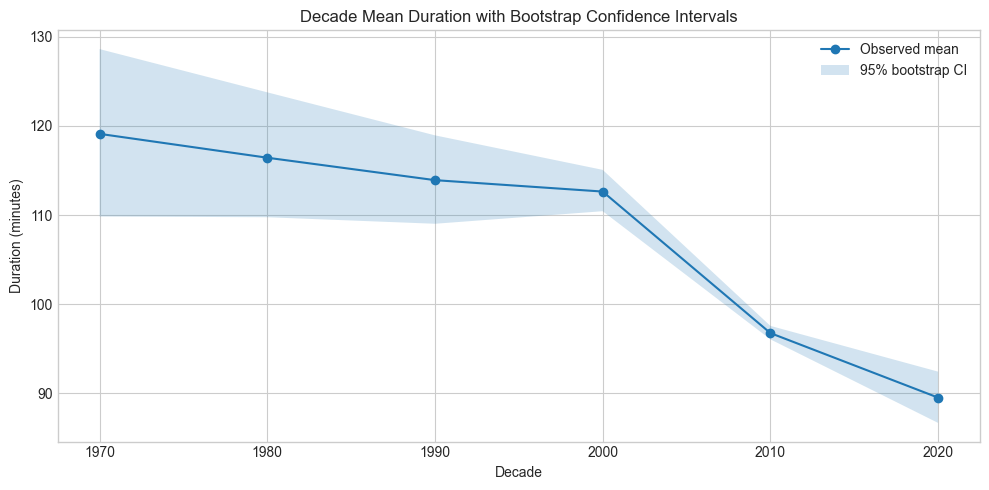

In [131]:
# Bootstrap confidence intervals for decade-level average durations.
decade_summary = (
    movies.groupby("decade")
    .agg(n=("duration", "size"), mean_duration=("duration", "mean"), median_duration=("duration", "median"))
)

ci_bounds = movies.groupby("decade")["duration"].apply(bootstrap_mean_ci)
decade_summary["ci_low"] = ci_bounds.apply(lambda x: x[0])
decade_summary["ci_high"] = ci_bounds.apply(lambda x: x[1])
decade_summary = decade_summary.reset_index().sort_values("decade")

display(decade_summary.round(2))

# Plot decades with adequate sample size to avoid sparse-period distortion.
decade_plot = decade_summary[decade_summary["n"] >= 50].copy()

plt.figure(figsize=(10, 5))
plt.plot(decade_plot["decade"], decade_plot["mean_duration"], marker="o", label="Observed mean")
plt.fill_between(
    decade_plot["decade"],
    decade_plot["ci_low"],
    decade_plot["ci_high"],
    alpha=0.2,
    label="95% bootstrap CI",
)
plt.title("Decade Mean Duration with Bootstrap Confidence Intervals")
plt.xlabel("Decade")
plt.ylabel("Duration (minutes)")
plt.legend()
plt.tight_layout()
plt.savefig("plots/deep_decade_bootstrap_ci.png", dpi=150)
plt.show()

,decade,observed_mean,genre_standardized_mean,composition_effect,n
0,1940,51.38,62.17,-10.78,13
1,1950,107.09,125.44,-18.35,11
2,1960,142.36,148.09,-5.72,22
3,1970,119.11,115.76,3.35,63
4,1980,116.43,109.31,7.12,99
5,1990,113.92,107.66,6.26,194
6,2000,112.64,108.35,4.29,601
7,2010,96.76,97.72,-0.95,3951
8,2020,89.52,94.44,-4.92,423


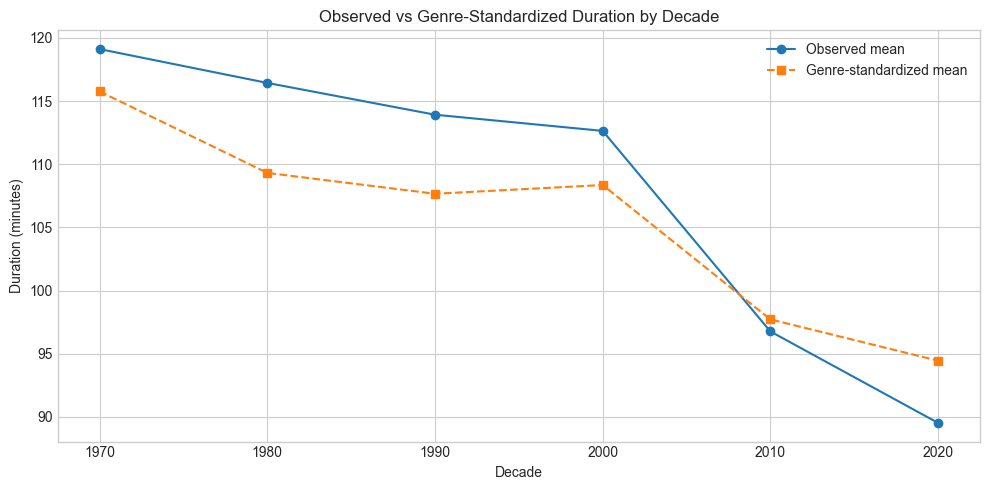

In [132]:
# Composition adjustment: hold genre mix constant at global catalog proportions.
genre_weights = movies["genre"].value_counts(normalize=True)

decade_genre_mean = (
    movies.groupby(["decade", "genre"])["duration"]
    .mean()
    .unstack("genre")
)

# Reindex columns to full weight vector so matrix multiplication is aligned.
decade_genre_mean = decade_genre_mean.reindex(columns=genre_weights.index)
weighted_sum = decade_genre_mean.mul(genre_weights, axis=1).sum(axis=1, min_count=1)
available_weight_mass = (
    decade_genre_mean.notna()
    .mul(genre_weights, axis=1)
    .sum(axis=1)
)
standardized_mean = weighted_sum / available_weight_mass

composition_compare = (
    movies.groupby("decade")["duration"].mean().rename("observed_mean")
    .to_frame()
    .join(standardized_mean.rename("genre_standardized_mean"))
    .dropna()
    .reset_index()
)
composition_compare["composition_effect"] = (
    composition_compare["observed_mean"] - composition_compare["genre_standardized_mean"]
)

composition_compare = composition_compare.merge(decade_summary[["decade", "n"]], on="decade", how="left")
display(composition_compare.round(2))

composition_plot = composition_compare[composition_compare["n"] >= 50].copy()

plt.figure(figsize=(10, 5))
plt.plot(composition_plot["decade"], composition_plot["observed_mean"], marker="o", label="Observed mean")
plt.plot(
    composition_plot["decade"],
    composition_plot["genre_standardized_mean"],
    marker="s",
    linestyle="--",
    label="Genre-standardized mean",
)
plt.title("Observed vs Genre-Standardized Duration by Decade")
plt.xlabel("Decade")
plt.ylabel("Duration (minutes)")
plt.legend()
plt.tight_layout()
plt.savefig("plots/deep_genre_standardized_trend.png", dpi=150)
plt.show()

,country,titles,years_modeled,slope_minutes_per_year,mean_duration
0,United States,2100,36,-0.845,90.689
1,India,883,24,-1.118,126.923
2,United Kingdom,341,12,-1.129,94.152
3,Unknown,230,10,-1.758,80.226
4,Canada,175,8,-4.573,86.749


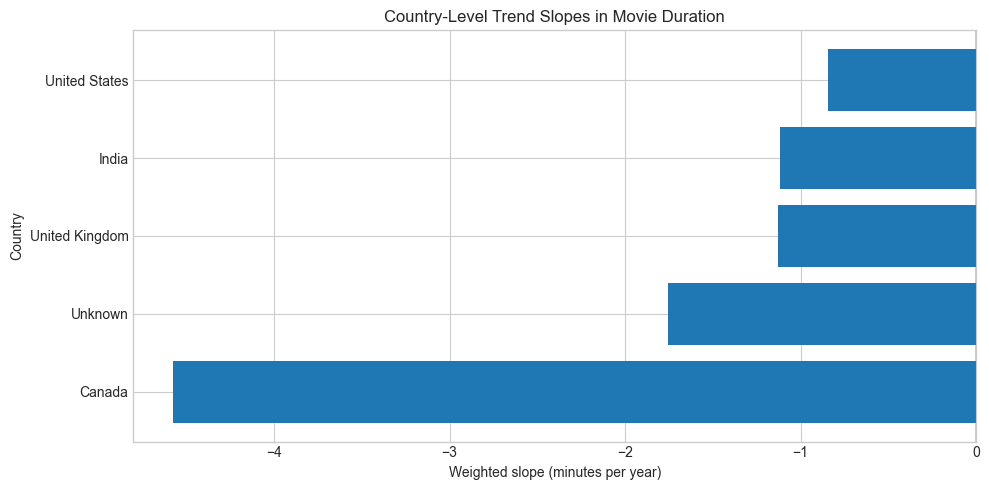

In [133]:
# Country heterogeneity: trend slopes for countries with enough titles and years.
country_counts = movies["primary_country"].value_counts()
eligible_countries = country_counts[country_counts >= 120].index

country_slopes = []
for country in eligible_countries:
    subset = movies[movies["primary_country"] == country]
    yearly_country = subset.groupby("release_year").agg(n=("duration", "size"), mean_duration=("duration", "mean")).reset_index()
    yearly_country = yearly_country[yearly_country["n"] >= 5]

    if len(yearly_country) < 8:
        continue

    slope, intercept = np.polyfit(
        yearly_country["release_year"],
        yearly_country["mean_duration"],
        deg=1,
        w=yearly_country["n"],
    )

    country_slopes.append(
        {
            "country": country,
            "titles": int(country_counts[country]),
            "years_modeled": int(len(yearly_country)),
            "slope_minutes_per_year": float(slope),
            "mean_duration": float(subset["duration"].mean()),
        }
    )

country_trend_df = pd.DataFrame(country_slopes).sort_values("titles", ascending=False)
display(country_trend_df.round(3))

plt.figure(figsize=(10, 5))
plot_df = country_trend_df.sort_values("slope_minutes_per_year")
plt.barh(plot_df["country"], plot_df["slope_minutes_per_year"])
plt.axvline(0, color="black", linewidth=1)
plt.title("Country-Level Trend Slopes in Movie Duration")
plt.xlabel("Weighted slope (minutes per year)")
plt.ylabel("Country")
plt.tight_layout()
plt.savefig("plots/deep_country_trend_slopes.png", dpi=150)
plt.show()

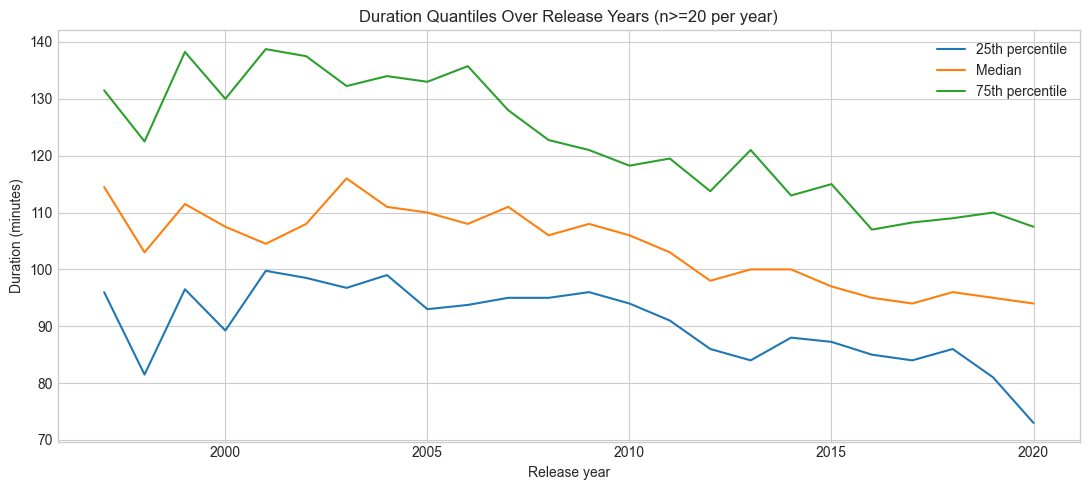

In [134]:
# Distributional trend: quantile trajectories in years with enough observations.
quantile_trends = (
    movies.groupby("release_year")["duration"]
    .quantile([0.25, 0.5, 0.75])
    .unstack()
    .rename(columns={0.25: "q25", 0.5: "q50", 0.75: "q75"})
    .reset_index()
)

yearly_counts = movies.groupby("release_year").size().rename("n").reset_index()
quantile_trends = quantile_trends.merge(yearly_counts, on="release_year", how="left")
quantile_trends = quantile_trends[quantile_trends["n"] >= 20]

plt.figure(figsize=(11, 5))
plt.plot(quantile_trends["release_year"], quantile_trends["q25"], label="25th percentile")
plt.plot(quantile_trends["release_year"], quantile_trends["q50"], label="Median")
plt.plot(quantile_trends["release_year"], quantile_trends["q75"], label="75th percentile")
plt.title("Duration Quantiles Over Release Years (n>=20 per year)")
plt.xlabel("Release year")
plt.ylabel("Duration (minutes)")
plt.legend()
plt.tight_layout()
plt.savefig("plots/deep_quantile_trends.png", dpi=150)
plt.show()

## Final Verdict

Integrated conclusion from descriptive and inferential evidence:

1. **Yes, runtimes trend shorter in the modern Netflix movie catalog.**
2. **No, the trend is not a simple collapse.** It is moderate, noisy, and period-dependent.
3. **Composition matters materially.** Genre and country mix explain a meaningful share of observed movement.
4. **Inference must be sample-aware.** Stable-year filtering is essential because early decades are sparse.

Investigation takeaway:
- The strongest statement is not "movies are just getting shorter." The stronger, data-scientific claim is:

**Netflix runtime evolution is a blended outcome of time effects plus catalog-composition dynamics, with uncertainty that must be explicitly modeled.**